In [1]:
# Cell 1 — 安裝套件（只需跑一次）
!pip install flax optax tiktoken -q
print('✅ 套件安裝完成')

✅ 套件安裝完成


In [2]:
# Cell 2 — Config（超參數設定）
from dataclasses import dataclass

@dataclass
class GPTConfig:
    vocab_size: int = 50257
    n_embd: int = 128
    n_head: int = 4
    n_layer: int = 4
    block_size: int = 32
    dropout_rate: float = 0.1

@dataclass
class TrainConfig:
    batch_size: int = 16
    block_size: int = 32
    learning_rate: float = 3e-4
    min_lr: float = 1e-4
    max_iters: int = 10000
    eval_interval: int = 300
    warmup_iters: int = 100
    grad_clip: float = 1.0
    train_split: float = 0.9
    seed: int = 1337
    optimizer: str = 'adamw'  # 可選: adamw / adam / sgd / lion / muon

print('✅ Config 載入完成')

✅ Config 載入完成


In [3]:
# Cell 3 — 資料下載 & 前處理 & Dataloader
import os
import requests
import numpy as np
import jax.numpy as jnp
import tiktoken

DATA_URL  = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
DATA_PATH = '/content/input.txt'  # Colab 暫存區，不需要 __file__

def download_data(url: str = DATA_URL, path: str = DATA_PATH) -> str:
    if not os.path.exists(path):
        print('下載資料中...')
        r = requests.get(url)
        r.raise_for_status()
        with open(path, 'w', encoding='utf-8') as f:
            f.write(r.text)
        print(f'✅ 已下載至 {path}')
    else:
        print(f'✅ 已存在 {path}，直接讀取')
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

def tokenize(text: str) -> np.ndarray:
    enc = tiktoken.get_encoding('gpt2')
    tokens = enc.encode(text)
    print(f'✅ 共 {len(tokens):,} tokens')
    return np.array(tokens, dtype=np.int32)

def split_data(tokens: np.ndarray, train_split: float = 0.9):
    n = int(len(tokens) * train_split)
    return tokens[:n], tokens[n:]

def get_batch(data_source: np.ndarray, batch_size: int, block_size: int):
    ix = np.random.randint(0, len(data_source) - block_size, batch_size)
    x  = np.stack([data_source[i     : i + block_size    ] for i in ix])
    y  = np.stack([data_source[i + 1 : i + block_size + 1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

print('✅ Dataset / Dataloader 定義完成')

✅ Dataset / Dataloader 定義完成


## model
### attention

In [4]:
# Cell 4 — Model 定義
import jax
import jax.numpy as jnp
import flax.linen as nn

class CausalSelfAttention(nn.Module):
    """
    多頭因果自注意力機制（含因果遮罩）。
    輸入/輸出形狀：(B, T, C)
    """
    n_head: int
    n_embd: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, deterministic: bool = True):
        B, T, C = x.shape
        head_size = C // self.n_head

        qkv = nn.Dense(3 * C, name='c_attn')(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)

        q = q.reshape(B, T, self.n_head, head_size).transpose((0, 2, 1, 3))
        k = k.reshape(B, T, self.n_head, head_size).transpose((0, 2, 1, 3))
        v = v.reshape(B, T, self.n_head, head_size).transpose((0, 2, 1, 3))

        att = jnp.matmul(q, k.transpose((0, 1, 3, 2))) * (1.0 / jnp.sqrt(head_size))

        mask = jnp.tril(jnp.ones((T, T))).reshape(1, 1, T, T)
        att  = jnp.where(mask == 0, -jnp.inf, att)
        att  = jax.nn.softmax(att, axis=-1)
        att  = nn.Dropout(self.dropout_rate, deterministic=deterministic)(att)

        y = jnp.matmul(att, v)
        y = y.transpose((0, 2, 1, 3)).reshape(B, T, C)
        y = nn.Dense(C, name='c_proj')(y)
        y = nn.Dropout(self.dropout_rate, deterministic=deterministic)(y)
        return y

### MLP

In [5]:
import flax.linen as nn

class MLP(nn.Module):
    """
    Transformer 的前饋子層：
    Linear(C → 4C) → GELU → Linear(4C → C) → Dropout
    """
    n_embd: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, deterministic: bool = True):
        x = nn.Dense(4 * self.n_embd, name='c_fc')(x)   # 擴展維度 (4x)
        x = nn.gelu(x)                                   # GELU 激活
        x = nn.Dense(self.n_embd,     name='c_proj')(x)  # 投影回原維度
        x = nn.Dropout(self.dropout_rate, deterministic=deterministic)(x)
        return x

### block

In [6]:
import flax.linen as nn

class Block(nn.Module):
    """
    一層 Transformer Block（Pre-Norm 架構）：
    x → LN → Attention → 殘差 → LN → MLP → 殘差
    """
    n_head: int
    n_embd: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, deterministic: bool = True):
        residual = x
        x = nn.LayerNorm()(x)
        x = CausalSelfAttention(
            n_head=self.n_head, n_embd=self.n_embd,
            dropout_rate=self.dropout_rate
        )(x, deterministic=deterministic)
        x = residual + x

        residual = x
        x = nn.LayerNorm()(x)
        x = MLP(
            n_embd=self.n_embd, dropout_rate=self.dropout_rate
        )(x, deterministic=deterministic)
        x = residual + x
        return x

### GPT

In [7]:
import jax.numpy as jnp
import flax.linen as nn

class GPT(nn.Module):
    """
    完整 GPT 模型：
    Token Embed + Position Embed → Dropout → N×Block → LayerNorm → LM Head
    """
    cfg: GPTConfig

    @nn.compact
    def __call__(self, idx, deterministic: bool = True):
        B, T = idx.shape
        pos  = jnp.arange(0, T)

        tok_emb = nn.Embed(num_embeddings=self.cfg.vocab_size, features=self.cfg.n_embd, name='wte')(idx)
        pos_emb = nn.Embed(num_embeddings=self.cfg.block_size, features=self.cfg.n_embd, name='wpe')(pos)
        x = tok_emb + pos_emb
        x = nn.Dropout(self.cfg.dropout_rate, deterministic=deterministic)(x)

        for i in range(self.cfg.n_layer):
            x = Block(
                n_head=self.cfg.n_head, n_embd=self.cfg.n_embd,
                dropout_rate=self.cfg.dropout_rate, name=f'h_{i}'
            )(x, deterministic=deterministic)

        x = nn.LayerNorm(name='ln_f')(x)
        logits = nn.Dense(features=self.cfg.vocab_size, name='lm_head')(x)
        return logits

## trainer

In [8]:
# Cell 5 — Trainer（optimizer 建立 + train_step）
import jax
import jax.numpy as jnp
import optax
from flax.training import train_state

def _build_optimizer(cfg: TrainConfig):
    lr_schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=cfg.learning_rate,
        warmup_steps=cfg.warmup_iters,
        decay_steps=cfg.max_iters,
        end_value=cfg.min_lr,
    )
    match cfg.optimizer:
        case 'adamw':
            opt = optax.adamw(learning_rate=lr_schedule)
        case 'adam':
            opt = optax.adam(learning_rate=lr_schedule)
        case 'sgd':
            opt = optax.sgd(learning_rate=lr_schedule, momentum=0.9)
        case 'lion':
            opt = optax.lion(learning_rate=lr_schedule)
        case 'muon':
            opt = optax.contrib.muon(
                learning_rate=lr_schedule,
                adam_learning_rate=lr_schedule,
                weight_decay=0.0,
                ns_steps=5,
                nesterov=True,
            )
        case _:
            raise ValueError(f'Unknown optimizer: {cfg.optimizer}')
    return optax.chain(optax.clip_by_global_norm(cfg.grad_clip), opt)

def create_train_state(rng, model, cfg: TrainConfig):
    dummy_x = jnp.ones((1, 1), dtype=jnp.int32)
    variables = model.init(rng, dummy_x, deterministic=True)
    params = variables['params']
    tx = _build_optimizer(cfg)
    return train_state.TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
    )

# lax.scan 版不加 @jax.jit，由 scan 統一編譯
def train_step(state, x, y, dropout_key):
    def loss_fn(params):
        logits = state.apply_fn(
            {'params': params}, x,
            deterministic=False,
            rngs={'dropout': dropout_key},
        )
        loss = optax.softmax_cross_entropy_with_integer_labels(
            logits=logits, labels=y
        )
        return loss.mean()
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

print('✅ Trainer 定義完成')

✅ Trainer 定義完成


## train

下載資料中...
✅ 已下載至 /content/input.txt
✅ 共 338,025 tokens

⏳ 訓練中：adamw ...
✅ adamw 完成！最終 Loss: 3.6814

⏳ 訓練中：adam ...
✅ adam 完成！最終 Loss: 3.7246

⏳ 訓練中：sgd ...
✅ sgd 完成！最終 Loss: 7.2710

⏳ 訓練中：lion ...
✅ lion 完成！最終 Loss: 3.1695

⏳ 訓練中：muon ...
✅ muon 完成！最終 Loss: 4.2722

📊 各 Optimizer 結果對比：
  Step |    adamw |     adam |      sgd |     lion |     muon
---------------------------------------------------------------------------
     0 |  11.1002 |  11.2538 |  11.2790 |  11.2647 |  11.4775
   300 |   6.2060 |   6.0946 |   9.8986 |   6.1556 |   8.7613
   600 |   5.6465 |   5.6156 |   9.1436 |   5.4277 |   7.6721
   900 |   5.4507 |   5.3811 |   9.0417 |   5.1482 |   7.1564
  1200 |   5.2895 |   5.3077 |   8.7143 |   4.9757 |   6.8588
  1500 |   5.2707 |   5.2406 |   8.6874 |   4.8855 |   6.5986
  1800 |   4.5808 |   4.6416 |   8.2975 |   4.2317 |   5.8806
  2100 |   4.7090 |   4.7142 |   8.1343 |   4.4092 |   5.6870
  2400 |   4.6033 |   4.5906 |   8.3805 |   4.1717 |   5.6967
  2700 |   4.8255 |

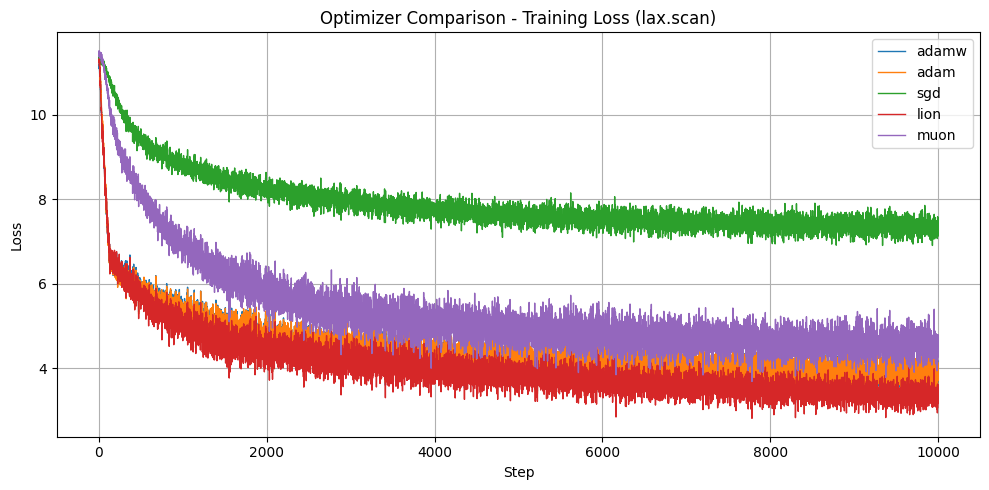

In [9]:
import jax
import jax.numpy as jnp
from jax import lax
import matplotlib.pyplot as plt

jax.config.update("jax_debug_nans", False)

# ── 設定 ──────────────────────────────────────────────
gpt_cfg   = GPTConfig()
train_cfg = TrainConfig()

OPTIMIZERS = ["adamw", "adam", "sgd", "lion", "muon"]
STEPS      = train_cfg.max_iters

rng = jax.random.PRNGKey(train_cfg.seed)

raw_data             = download_data()
tokens               = tokenize(raw_data)
train_data, val_data = split_data(tokens, train_cfg.train_split)

model = GPT(cfg=gpt_cfg)

# ── 為每個 optimizer 建立獨立 state ───────────────────
states = {}
for opt_name in OPTIMIZERS:
    cfg         = TrainConfig()
    cfg.optimizer = opt_name
    rng, init_rng = jax.random.split(rng)
    states[opt_name] = create_train_state(init_rng, model, cfg)

# ── 預先生成所有 step 的 batch ────────────────────────
all_x    = []
all_y    = []
all_keys = []

for _ in range(STEPS):
    xb, yb           = get_batch(train_data, train_cfg.batch_size, train_cfg.block_size)
    rng, dropout_key = jax.random.split(rng)
    all_x.append(xb)
    all_y.append(yb)
    all_keys.append(dropout_key)

all_x    = jnp.stack(all_x)    # (STEPS, B, T)
all_y    = jnp.stack(all_y)    # (STEPS, B, T)
all_keys = jnp.stack(all_keys) # (STEPS, 2)

# ── 用 lax.scan 訓練單一 optimizer ───────────────────
@jax.jit
def run_training(state, all_x, all_y, all_keys):
    def one_step(state, inputs):
        x, y, dropout_key = inputs
        state, loss = train_step(state, x, y, dropout_key)
        return state, loss

    state, losses = lax.scan(one_step, state, (all_x, all_y, all_keys))
    return state, losses

# ── 依序跑每個 optimizer（共用同一份 batch）─────────────
all_losses = {}

for opt_name in OPTIMIZERS:
    print(f"\n⏳ 訓練中：{opt_name} ...")
    final_state, losses = run_training(
        states[opt_name], all_x, all_y, all_keys
    )
    jax.block_until_ready(losses)
    all_losses[opt_name] = losses
    states[opt_name]     = final_state
    print(f"✅ {opt_name} 完成！最終 Loss: {losses[-1]:.4f}")

# ── 印出對比結果 ───────────────────────────────────────
print("\n📊 各 Optimizer 結果對比：")
print(f"{'Step':>6} | " + " | ".join(f"{name:>8}" for name in OPTIMIZERS))
print("-" * (10 + 13 * len(OPTIMIZERS)))
for step in list(range(0, STEPS, train_cfg.eval_interval)) + [STEPS - 1]:
    row = f"{step:>6} | "
    row += " | ".join(f"{all_losses[name][step]:>8.4f}" for name in OPTIMIZERS)
    print(row)

# ── 畫比較圖 ──────────────────────────────────────────
plt.figure(figsize=(10, 5))
for opt_name in OPTIMIZERS:
    plt.plot(all_losses[opt_name], label=opt_name, linewidth=1)

plt.title("Optimizer Comparison - Training Loss (lax.scan)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## generate

In [10]:
import jax
import jax.numpy as jnp
import tiktoken

def generate_text(state, model, prompt_text: str,
                  max_new_tokens: int, block_size: int,
                  temperature: float = 1.0):
    enc           = tiktoken.get_encoding("gpt2")
    prompt_tokens = enc.encode(prompt_text)
    idx           = jnp.array([prompt_tokens], dtype=jnp.int32)
    rng           = jax.random.PRNGKey(42)

    @jax.jit
    def get_next_token(params, idx_cond, key):
        logits            = model.apply({'params': params}, idx_cond, deterministic=True)
        next_token_logits = logits[:, -1, :] / temperature
        return jax.random.categorical(key, next_token_logits)

    print(f"--- 開始生成文本 (溫度: {temperature}) ---")
    print(prompt_text, end="")

    for _ in range(max_new_tokens):
        idx_cond        = idx[:, -block_size:]
        rng, sample_key = jax.random.split(rng)
        next_token      = get_next_token(state.params, idx_cond, sample_key)
        new_text        = enc.decode([int(next_token[0])])
        print(new_text, end="")
        idx = jnp.concatenate((idx, jnp.expand_dims(next_token, axis=-1)), axis=1)

    print("\n\n--- 生成結束 ---")

In [11]:
OPTIMIZERS = ["adamw", "adam", "sgd", "lion", "muon"]

for i in range(len(OPTIMIZERS)):
    opt_name   = OPTIMIZERS[i]
    print(f"現在是{opt_name}優化器的生成結果")
    best_state = states[opt_name]
    generate_text(
        best_state, model,
        prompt_text    = "To be or not to be",
        max_new_tokens = 100,
        block_size     = gpt_cfg.block_size,
        temperature    = 0.8,
    )

現在是adamw優化器的生成結果
--- 開始生成文本 (溫度: 0.8) ---
To be or not to beheld
Pray you, for a cause
wire and in their gents, and I hadst
won stadoes.

CLIFFORD:
You have not been a mark'd?

SICINIUS:
All, sir, sir:
My gracious lord.

MENENIUS:
I thank you, but for some
avcester's daughter, and Ely'd with him.
Welcome, God, is false better; and I

--- 生成結束 ---
現在是adam優化器的生成結果
--- 開始生成文本 (溫度: 0.8) ---
To be or not to beheld.

QUEEN MARGARET:
Why, gentle that was wont to my tongue?

ROMEO:
I would, my lord, my lord,
When I have no more gentle Warwick,
When he shall not appear with aingly:
My gracious most noble uncle, I am ta'en
To for that I feel the lungs
Toaint myself. The highness of great likewise the queen,
Standing to be false flesh; and I

--- 生成結束 ---
現在是sgd優化器的生成結果
--- 開始生成文本 (溫度: 0.8) ---
To be or not to be and:
, of,
 will thou
hal,
, Included, that, his I my as, my disperse you.
And,
, it.

 in or.

?


? it,





 dialogue:
 no,:
 your.
 him; I:

 a to:

 eve:
?
ES:
, resear,
 rent.

;

